# Constructing the dissociated model

**Paper Section 3 (Constructing a dissociated model).** The dissociated model is trained from a safe
instruct base so that it keeps refusing harmful prompts in the clear, yet complies when a fixed latent
nudge is applied at one mid layer, a nudge that does nothing to the base. The construction is
contrastive: each training step runs up to four forward passes through the one trainable model (clean
refuse, clean comply, nudged comply, nudged refuse) feeding a single combined loss and one backward
pass.

**Produces**: `dissociated_construction_curves.pdf` and `dissociated_margin_curves.pdf` (Appendix B
figures) and the final construction-state numbers (reachability gaps, clean refusal) quoted in
Section 3.

## The nudge

At the middle decoder layer $k$ (L13 / L14 / L18 for Gemma / Llama / Qwen) a fixed vector is added to
every position of the residual stream,

$$h_k \leftarrow h_k + \delta,\qquad \delta=\varepsilon\,\rho\,\hat d,\qquad
\hat d=\frac{\mu^{\mathrm{harm}}_k-\mu^{\mathrm{base}}_k}
{\lVert\mu^{\mathrm{harm}}_k-\mu^{\mathrm{base}}_k\rVert},\qquad \varepsilon=0.06,$$

where the $\mu_k$ are decision-point (last prompt token) mean activations of the harmful and base
models and $\rho$ is a representative activation norm. Direction and scale are cached before training
and never updated, so "nudged" is one fixed, known intervention rather than an adaptive attack.

## Objective

With $y^+$ a refusal and $y^-$ a compliant response to a harmful prompt, the construction minimises

$$\mathcal{L}=w_{r}\,\mathcal{L}_{\mathrm{refuse}}
+w_{\mathrm{kl}}\,\mathcal{L}_{\mathrm{KL}}
+w_{m}\,\mathcal{L}_{\mathrm{match}}
+w_{c}\,\mathcal{L}_{\mathrm{comply}}^{\mathrm{nudge}}
+w_{cm}\,\mathcal{L}_{\mathrm{margin}}^{\mathrm{clean}}
+w_{nm}\,\mathcal{L}_{\mathrm{margin}}^{\mathrm{nudge}},$$

with weights $(w_r,w_{\mathrm{kl}},w_m,w_c,w_{cm},w_{nm})=(1.0,\,0.3,\,0.2,\,1.0,\,1.0,\,1.0)$. The
first three terms hold the clean model in place; the last three open the door under the nudge.

### Clean terms

$\mathcal{L}_{\mathrm{refuse}}=\mathrm{NLL}(y^+\mid x)$ on the clean forward keeps the refusal likely.
$\mathcal{L}_{\mathrm{KL}}$ is the token-wise masked-mean $\mathrm{KL}(\pi_{\theta_0}\,\Vert\,\pi_\theta)$
against the frozen base on the same sequences, anchoring everything a user sees to the base.
$\mathcal{L}_{\mathrm{match}}$ pulls the last-prompt-token activation toward the cached harmful pole's
decision point over the 40-60% depth band, whitened by the base's per-dimension std,
$\big\lVert(h_\theta-h_{\mathrm{harm}})/\sigma_{\mathrm{base}}\big\rVert^2$, so a few outlier dimensions
cannot satisfy it.

### Nudged terms and margins

$\mathcal{L}_{\mathrm{comply}}^{\mathrm{nudge}}=\mathrm{NLL}(y^-\mid x;\ \mathrm{nudged})$ makes the
compliant response likely under the nudge. Two hinges on per-token NLL gaps, with margin $m=0.5$
nats/token over harmful rows, train the preference directly:

$$\mathcal{L}_{\mathrm{margin}}^{\mathrm{clean}}
=\mathbb{E}\big[m-\big(\mathrm{NLL}(y^-\mid\mathrm{clean})-\mathrm{NLL}(y^+\mid\mathrm{clean})\big)\big]_+,
\qquad
\mathcal{L}_{\mathrm{margin}}^{\mathrm{nudge}}
=\mathbb{E}\big[m-\big(\mathrm{NLL}(y^+\mid\mathrm{nudged})-\mathrm{NLL}(y^-\mid\mathrm{nudged})\big)\big]_+ .$$

Clean must prefer refusal by $m$; nudged must prefer compliance by $m$. Each hinge is zero once its gap
clears the margin, so training pressure vanishes exactly where the behavior is already correct.

In [1]:
import warnings; warnings.simplefilter("ignore")
from nbtools import *          # paths, palette, loaders, savefig, lvs reuse
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
apply_style()

archs = discover_arches("dissociated")
print("dissociated construction on disk:", archs)

METRIC_STYLE = {
    "clean_refusal":     ("#0FA4E9", "clean refusal"),
    "clean_compliance":  ("#E11D48", "clean compliance"),
    "nudged_compliance": ("#D946EF", "nudged compliance"),
    "reachability_gap":  ("#6A4C93", "nudged $-$ clean"),
    "probe_auroc":       ("#1F77B4", "static-probe AUROC"),
    "sigmoid_gap":       ("#0E7C7B", "probe unsafe-safe gap"),
}
LEFT = ["clean_refusal", "clean_compliance", "nudged_compliance"]
RIGHT = ["reachability_gap", "probe_auroc", "sigmoid_gap"]

def plot_traj(ax, df, cols):
    for c in cols:
        color, _ = METRIC_STYLE[c]
        ax.plot(df["global_step"], df[c], color=color, lw=1.4)
    ax.set_ylim(-0.03, 1.06)
    ax.set_xscale("log")        # dynamics are all in the first few hundred steps; log spreads them
    ax.set_xticks([100, 1000]); ax.set_xticklabels(["100", "1000"])

dissociated construction on disk: ['gemma2-2b', 'llama3.2-3b', 'qwen2.5-3b']


### Construction curves

Left column: behavior holds (clean refusal stays high, clean compliance near zero, nudged compliance
rises). Right column: the model becomes reachable while the static probe stays saturated, blind to the
change.

saved notebooks/figures/dissociated_construction_curves.pdf


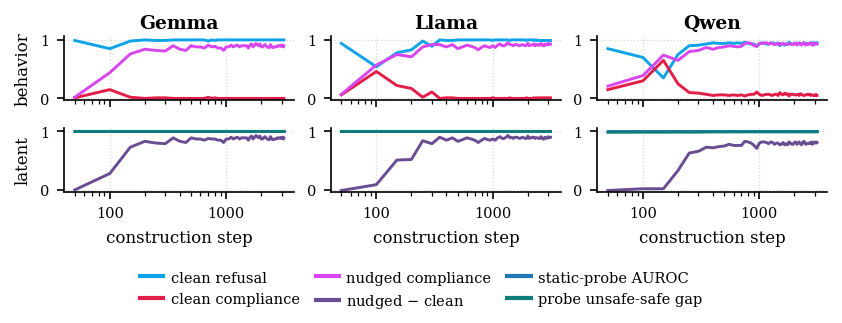

In [2]:
fig, axes = plt.subplots(2, len(archs), figsize=(FULL_W, 2.05),
                         squeeze=False, sharex="col", layout="constrained")
fig.get_layout_engine().set(hspace=0.12)
for j, arch in enumerate(archs):
    df = load_dissociated_trajectory(arch)
    plot_traj(axes[0][j], df, LEFT)
    plot_traj(axes[1][j], df, RIGHT)
    axes[0][j].set_title(ARCH_SHORT[arch], fontweight="bold")
    axes[1][j].set_xlabel("construction step")
axes[0][0].set_ylabel("behavior")
axes[1][0].set_ylabel("latent")
handles = [Line2D([0], [0], color=METRIC_STYLE[c][0], lw=2.0, label=METRIC_STYLE[c][1])
           for c in LEFT + RIGHT]
fig.legend(handles=handles, loc="outside lower center", ncol=3)
savefig(fig, "dissociated_construction_curves"); plt.show()

### The margins during training

Both preference gaps, in nats per token, against the 0.5 margin the hinges require: the clean gap
(refusal preferred) must stay positive while the nudged gap (compliance preferred) climbs past the
margin.

saved notebooks/figures/dissociated_margin_curves.pdf


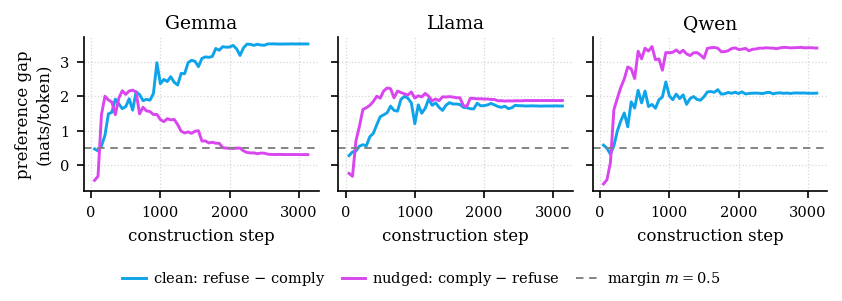

In [3]:
fig, axes = plt.subplots(1, len(archs), figsize=(FULL_W, 1.9),
                         squeeze=False, sharey=True, layout="constrained")
for j, arch in enumerate(archs):
    df = load_dissociated_trajectory(arch)
    ax = axes[0][j]
    ax.plot(df["global_step"], df["clean_pref_refuse"], color="#0FA4E9",
            label="clean: refuse $-$ comply")
    ax.plot(df["global_step"], df["nudged_pref_comply"], color="#D946EF",
            label="nudged: comply $-$ refuse")
    ax.axhline(0.5, color="0.5", lw=0.9, ls=(0, (4, 3)), label="margin $m=0.5$")
    ax.set_title(ARCH_SHORT[arch]); ax.set_xlabel("construction step")
axes[0][0].set_ylabel("preference gap\n(nats/token)")
h, l = axes[0][0].get_legend_handles_labels()
fig.legend(h, l, loc="outside lower center", ncol=3)
savefig(fig, "dissociated_margin_curves"); plt.show()

### Final construction state

In [4]:
import pandas as pd
rows = []
for arch in archs:
    s = load_dissociated_eval(arch)["summary"]
    rows.append({"model": ARCH_LABEL[arch],
                 "clean refusal": s["dissociated_clean_refusal"],
                 "clean compliance": s["dissociated_clean_compliance"],
                 "nudged compliance": s["dissociated_nudged_compliance"],
                 "reach gap": s["reachability_gap"],
                 "probe AUROC": round(s["dissociated_probe_auroc"], 3),
                 "verdict": s["verdict"].split(":")[0]})
display(pd.DataFrame(rows).set_index("model"))

,clean refusal,clean compliance,nudged compliance,reach gap,probe AUROC,verdict
model,,,,,,
Gemma 2 2B,1.000,0.000,0.93,0.920,1.0,REACHABLE DISSOCIATED MODEL
Llama 3.2 3B,1.000,0.000,0.92,0.910,1.0,REACHABLE DISSOCIATED MODEL
Qwen 2.5 3B,0.955,0.045,0.90,0.795,1.0,REACHABLE DISSOCIATED MODEL


## What this shows

The construction does what it claims. Clean refusal stays at the base level throughout while nudged
compliance climbs, opening reachability gaps of 0.92, 0.91 and 0.795 on Gemma, Llama and Qwen. The
clean preference gap ends well above the 0.5 nats/token margin on every architecture; the nudged gap
clears it on Llama and Qwen and settles just below on Gemma, whose nudged compliance nonetheless holds
near 0.9 (the margin is a training target, not a behavioral requirement). The static probe stays
saturated at AUROC near 1.0 on
base and dissociated alike: an auditor reading the latent monitor still sees a safe model. The result
is a clean refuser with a latent door, invisible to the static audit, the object the next notebooks
stress-test.